In [1]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\reema\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reema\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\reema\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\reema\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
def preprocess_text(text):
    # step 1:Lowercase
    text = text.lower()
    # step 2:Remove punctuation
    text = text.translate(str.maketrans('','',string.punctuation))
    # step 3:Tokenization
    tokens = word_tokenize(text)
    # step 4:Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # step 5:Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

In [69]:
sample_text = "The professor of DS483 explained machine learning and Natural Language Processing algorithms clearly and gave real-world examples."
processed_tokens = preprocess_text(sample_text)
print(processed_tokens)

['professor', 'ds483', 'explained', 'machine', 'learning', 'natural', 'language', 'processing', 'algorithms', 'clearly', 'gave', 'realworld', 'examples']


In [11]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

vocab_size = 10000
max_review_length = 500

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = sequence.pad_sequences(X_train, maxlen=max_review_length)
X_test = sequence.pad_sequences(X_test, maxlen=max_review_length)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 25000
Testing samples: 25000


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

print("Randome Forest Results:")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf: .4f}")
print(f"Recall: {rec_rf:.4f}")

Randome Forest Results:
Accuracy: 0.5284
Precision:  0.5311
Recall: 0.4847


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

embedding_dim = 128
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim, input_length=max_review_length))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=128, epochs=5, validation_split=0.2, verbose=1)

loss, acc_lstm = model.evaluate(X_test, y_test, verbose=0)
y_pred_lstm = (model.predict(X_test) > 0.5).astype(int)
prec_lstm = precision_score(y_test, y_pred_lstm)
rec_lstm = recall_score(y_test, y_pred_lstm)

print("LSTM Results:")
print(f"Accuracy: {acc_lstm:.4f}")
print(f"Precision: {prec_lstm:.4f}")
print(f"Recall: {rec_lstm:.4f}")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.6612 - loss: 0.6096 - val_accuracy: 0.7658 - val_loss: 0.4834
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 406s 3s/step - accuracy: 0.8508 - loss: 0.3600 - val_accuracy: 0.8314 - val_loss: 0.3844
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 406s 3s/step - accuracy: 0.8803 - loss: 0.3003 - val_accuracy: 0.8386 - val_loss: 0.3879
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.8995 - loss: 0.2563 - val_accuracy: 0.8384 - val_loss: 0.3881
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 401s 3s/step - accuracy: 0.9190 - loss: 0.2167 - val_accuracy: 0.8458 - val_loss: 0.3871
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step
LSTM Results:
Accuracy: 0.8404
Precision: 0.8811
Recall: 0.7870


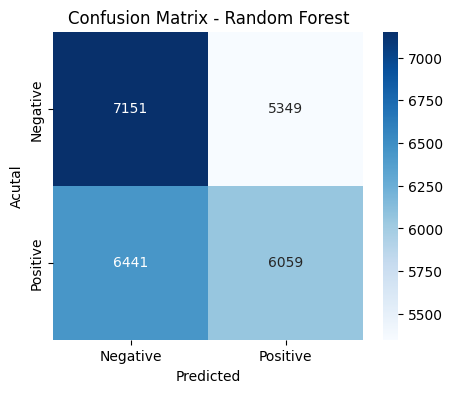

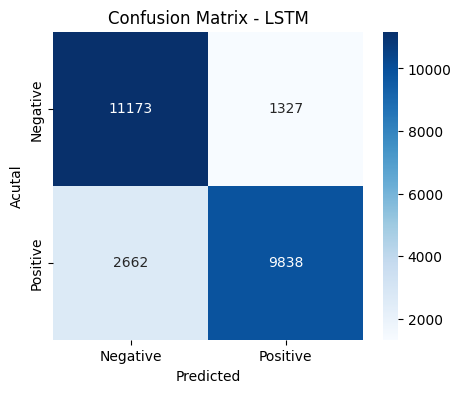

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Negative', 'Positive'],
               yticklabels=['Negative', 'Positive'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Acutal')
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Confusion Matrix - Random Forest')
plot_confusion_matrix(y_test, y_pred_lstm, 'Confusion Matrix - LSTM')

In [54]:
print("             Model Comparison    ")
print(f"{'Model':<15} {'Accuracy':<10} {'Recall':<10}")
print(f"{'Random Forest':<15} {acc_rf:<10.4f} {prec_rf:<10.4f} {rec_rf:<10.4f}")
print(f"{'LSTM':<15} {acc_lstm:<10.4f} {prec_lstm:<10.4f} {rec_lstm:<10.4f}")

             Model Comparison    
Model           Accuracy   Recall    
Random Forest   0.5284     0.5311     0.4847    
LSTM            0.8404     0.8811     0.7870    
